## Otimização de Modelo de Risco de Crédito - Caso Prático

# Optimización de Modelo de Riesgo Crediticio - Caso Práctico

## 1. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder # OneHotEncoder por si tuvieramos categóricas
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

# Para que los gráficos se muestren en el notebook
%matplotlib inline


## 2. Dataset

In [2]:
# np.random.seed(42)
# Explicación:
# - 'np.random.seed()' es una función de la librería NumPy (abreviada como 'np').
# - Su propósito es inicializar el generador de números pseudoaleatorios de NumPy.
# - Las computadoras no pueden generar números verdaderamente aleatorios por sí mismas; en su lugar,
#   utilizan algoritmos para producir secuencias de números que parecen aleatorios. Estas secuencias
#   son determinísticas si se conoce el punto de inicio, llamado "semilla" (seed).
# - Al establecer una semilla específica (aquí, el número 42, que es una elección común pero arbitraria),
#   nos aseguramos de que cada vez que se ejecute este código, la secuencia de números "aleatorios"
#   generada por las funciones de NumPy (como np.random.randint, np.random.lognormal, etc.)
#   será EXACTAMENTE LA MISMA.
# - ¿Por qué es importante? Para la REPRODUCIBILIDAD. Si queremos que nuestros resultados
#   (por ejemplo, la composición del dataset simulado, la división de los datos, la inicialización
#   de pesos en algunos modelos) sean consistentes entre ejecuciones o si otra persona
#   ejecuta este código, fijar la semilla es crucial.
np.random.seed(42)

# n_samples = 1000
# Explicación:
# - Esta línea está declarando una variable llamada 'n_samples'.
# - Se le asigna el valor entero 1000.
# - El nombre 'n_samples' es descriptivo e indica que esta variable representará el "número de muestras"
#   o "número de ejemplos/filas" que queremos generar para nuestro dataset simulado.
# - En las líneas siguientes del código, esta variable 'n_samples' se usará para determinar
#   el tamaño de los arrays de NumPy que se crearán para simular las características
#   de nuestros clientes (edad, salario, etc.).
# - Usar una variable como esta es una buena práctica porque si quisiéramos cambiar el tamaño
#   del dataset simulado (por ejemplo, a 5000 muestras), solo tendríamos que cambiar
#   el valor en esta única línea, en lugar de buscar y reemplazar '1000' en múltiples lugares.
n_samples = 1000

# Generamos datos con más variabilidad y algunas correlaciones implícitas
idades = np.random.randint(22, 65, n_samples)
salarios = np.random.lognormal(mean=np.log(5000), sigma=0.4, size=n_samples).astype(int)
divida_total = (salarios * np.random.uniform(0.1, 2.5, n_samples) * np.random.normal(1, 0.3, n_samples)).astype(int)
divida_total = np.clip(divida_total, 500, 50000)

prob_bom_historico = 0.4 + 0.3 * (salarios / (np.max(salarios)+1e-6)) - 0.2 * (divida_total / (salarios+1e-6)) + 0.1 * (idades / 65)
historico_bom = (np.random.rand(n_samples) < np.clip(prob_bom_historico, 0.1, 0.9)).astype(int)

score_latente = (
    -0.05 * (idades - np.mean(idades)) / np.std(idades) +
    0.3 * (salarios - np.mean(salarios)) / np.std(salarios) -
    0.4 * (divida_total - np.mean(divida_total)) / np.std(divida_total) +
    0.5 * historico_bom +
    np.random.normal(0, 0.5, n_samples)
)
prob_pagou = 1 / (1 + np.exp(-score_latente))
pagou = (prob_pagou > np.median(prob_pagou)).astype(int)

df = pd.DataFrame({
    'idade': idades,
    'salario_mensal': salarios,
    'divida_total': divida_total,
    'historico_bom': historico_bom,
    'pagou': pagou
})

print("--- Dataset Simulado (Primeras Filas) ---")
print(df.head())
print("\n--- Distribución de la Variable Objetivo 'pagou' ---")
print(df['pagou'].value_counts(normalize=True))

--- Dataset Simulado (Primeras Filas) ---
   idade  salario_mensal  divida_total  historico_bom  pagou
0     60            9643         19843              0      0
1     50            4922          3953              0      0
2     36            5177          8556              0      0
3     64            3422          1736              1      1
4     29            3660         11799              0      0

--- Distribución de la Variable Objetivo 'pagou' ---
pagou
0    0.5
1    0.5
Name: proportion, dtype: float64


## 3. Análisis Exploratorio de Datos (Conceptual)

In [3]:
# Importante hacer este analsis exploratorio
df.info()
df.describe()
# Visualizaciones: histogramas, boxplots, scatter plots, mapas de calor de correlación.
# (Ej: `sns.pairplot(df, hue='pagou', diag_kind='kde')`)
# Identificación de outliers, valores faltantes (y su tratamiento).

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   idade           1000 non-null   int32
 1   salario_mensal  1000 non-null   int64
 2   divida_total    1000 non-null   int64
 3   historico_bom   1000 non-null   int64
 4   pagou           1000 non-null   int64
dtypes: int32(1), int64(4)
memory usage: 35.3 KB


,idade,salario_mensal,divida_total,historico_bom,pagou
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,43.014000,5603.093000,7548.380000,0.322000,0.50000
std,12.333772,2437.004095,6366.439295,0.467477,0.50025
min,22.000000,1308.000000,500.000000,0.000000,0.00000
25%,32.000000,3913.250000,2885.500000,0.000000,0.00000
50%,44.000000,5095.000000,6068.500000,0.000000,0.50000
75%,54.000000,6805.000000,10240.750000,1.000000,1.00000
max,64.000000,17750.000000,50000.000000,1.000000,1.00000


In [4]:
# sns.pairplot(df, hue='pagou', diag_kind='kde')
# plt.show()

print("--- Descripción básica del DataFrame ---")
print(df.describe(include='all'))
print("\n--- Información del DataFrame ---")
df.info()

--- Descripción básica del DataFrame ---
             idade  salario_mensal  divida_total  historico_bom       pagou
count  1000.000000     1000.000000   1000.000000    1000.000000  1000.00000
mean     43.014000     5603.093000   7548.380000       0.322000     0.50000
std      12.333772     2437.004095   6366.439295       0.467477     0.50025
min      22.000000     1308.000000    500.000000       0.000000     0.00000
25%      32.000000     3913.250000   2885.500000       0.000000     0.00000
50%      44.000000     5095.000000   6068.500000       0.000000     0.50000
75%      54.000000     6805.000000  10240.750000       1.000000     1.00000
max      64.000000    17750.000000  50000.000000       1.000000     1.00000

--- Información del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   idade           1000 non-null   int32
 1   s

## 4. Ingeniería de Características
Crear nuevas características puede mejorar significativamente el modelo.

In [5]:
df['relacao_divida_salario'] = df['divida_total'] / (df['salario_mensal'] + 1e-6) # +1e-6 para evitar división por cero
df['idade_x_salario'] = df['idade'] * df['salario_mensal']

print("\n--- Dataset con Nuevas Características (Primeras Filas) ---")
print(df.head())


--- Dataset con Nuevas Características (Primeras Filas) ---
   idade  salario_mensal  divida_total  historico_bom  pagou  \
0     60            9643         19843              0      0   
1     50            4922          3953              0      0   
2     36            5177          8556              0      0   
3     64            3422          1736              1      1   
4     29            3660         11799              0      0   

   relacao_divida_salario  idade_x_salario  
0                2.057762           578580  
1                0.803129           246100  
2                1.652695           186372  
3                0.507306           219008  
4                3.223770           106140  


## 5. Preparación de Datos para el Modelo

In [6]:
# Separar variáveis X e y
X = df.drop('pagou', axis=1)
y = df['pagou']

# Identificar columnas numéricas
numeric_features = ['idade', 'salario_mensal', 'divida_total', 'relacao_divida_salario', 'idade_x_salario']
# 'historico_bom' es 0/1, se tratará como numérica por StandardScaler o se pasará directamente.

# Dividir en treino e teste ANTES de cualquier preprocesamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Tamaño del set de entrenamiento: {X_train.shape}")
print(f"Tamaño del set de prueba: {X_test.shape}")

Tamaño del set de entrenamiento: (750, 6)
Tamaño del set de prueba: (250, 6)


## 6. Creación de un Pipeline de Preprocesamiento y Modelado

In [7]:
# Preprocesador: StandardScaler para características numéricas.
# 'historico_bom' no está en numeric_features, así que 'remainder=passthrough' la mantendrá sin cambios.
# Si 'historico_bom' fuera una string ('Bueno'/'Malo'), necesitaría OneHotEncoding.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
        # ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) # Ejemplo si las hubiera
    ],
    remainder='passthrough' # Mantiene columnas no especificadas (ej: 'historico_bom' si no está en numeric_features)
)

# Modelo base
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced_subsample')

# Pipeline completo
pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', rf_model)])

## 7. Optimización de Hiperparámetros con Validación Cruzada (GridSearchCV)

In [8]:
# Definimos el espacio de búsqueda de hiperparámetros
param_grid = {
    'classifier__n_estimators': [100, 150],       # Reducido para ejecución más rápida en demo
    'classifier__max_depth': [5, 10],             # Reducido
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

# Validación cruzada estratificada
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) # n_splits=3 para demo

# GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=cv_strategy, scoring='roc_auc', n_jobs=-1, verbose=1)

print("\n--- Iniciando Optimización de Hiperparámetros... ---")
grid_search.fit(X_train, y_train)

print("\n--- Mejores Hiperparámetros Encontrados ---")
print(grid_search.best_params_)
best_model = grid_search.best_estimator_


--- Iniciando Optimización de Hiperparámetros... ---
Fitting 3 folds for each of 16 candidates, totalling 48 fits

--- Mejores Hiperparámetros Encontrados ---
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}


## 8. Evaluación Detallada del Modelo Optimizado en el Conjunto de Test


--- Evaluación en el Conjunto de Test ---

Accuracy Score:
0.7120

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.74      0.72       125
           1       0.72      0.69      0.70       125

    accuracy                           0.71       250
   macro avg       0.71      0.71      0.71       250
weighted avg       0.71      0.71      0.71       250


ROC AUC Score:
0.8047


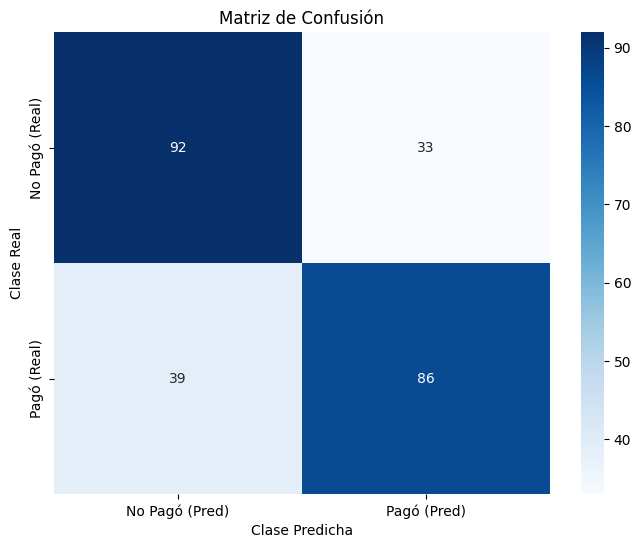

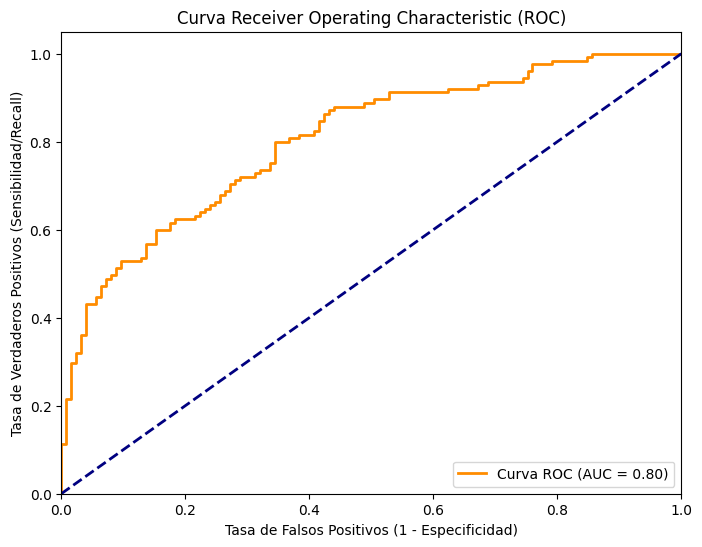

In [ ]:
print("\n--- Evaluación en el Conjunto de Test ---")
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1] # Probabilidades para la clase positiva (pagou=1)

print("\nAccuracy Score:")
print(f"{accuracy_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC AUC Score:")
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"{auc_score:.4f}")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Pagó (Pred)', 'Pagó (Pred)'],
            yticklabels=['No Pagó (Real)', 'Pagó (Real)'])
plt.title('Matriz de Confusión')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad/Recall)')
plt.title('Curva Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

## 9. Importancia de las Características


--- Importancia de las Características ---
                  feature  importance
3  relacao_divida_salario    0.373198
5           historico_bom    0.230680
2            divida_total    0.159372
1          salario_mensal    0.113416
4         idade_x_salario    0.069503
0                   idade    0.053831


C:\Users\Administrator\AppData\Local\Temp\ipykernel_12124\2018537123.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')


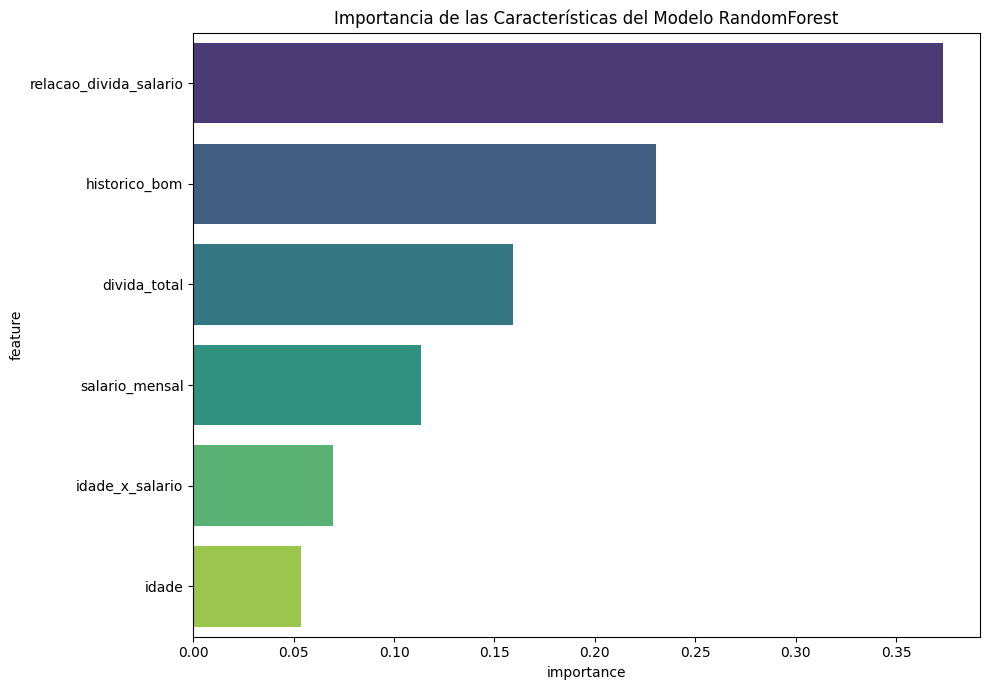

In [10]:
# Extraer el modelo RandomForest del pipeline
rf_classifier_optimized = best_model.named_steps['classifier']

# Obtener nombres de características después del preprocesamiento
# El preprocesador puede cambiar el orden o número de características.
# Para ColumnTransformer:
# - Las transformaciones se aplican en el orden listado en 'transformers'.
# - 'remainder="passthrough"' añade las columnas restantes al final, en su orden original.
ct_transformers = best_model.named_steps['preprocessor'].transformers_

feature_names_transformed = []
# Para la parte 'num' (StandardScaler)
numeric_features_out = best_model.named_steps['preprocessor'].transformers_[0][2] # Son los mismos que numeric_features
feature_names_transformed.extend(numeric_features_out)

# Para la parte 'remainder'
# 'remainder' columnas son aquellas en X_train.columns que NO están en numeric_features
if best_model.named_steps['preprocessor'].remainder == 'passthrough':
    # Necesitamos los índices de las columnas originales que fueron 'passthrough'
    # Esto puede ser un poco complejo si hay muchos transformadores.
    # Una forma más robusta es obtenerlas del transformador mismo si tiene `get_feature_names_out`
    # o construirlas manualmente con cuidado.
    
    # En este caso simple, las columnas 'passthrough' son las que no estaban en 'numeric_features'
    all_original_features = list(X_train.columns)
    passthrough_features = [f for f in all_original_features if f not in numeric_features]
    feature_names_transformed.extend(passthrough_features)
else: # si remainder es 'drop' o un transformador
    pass


importances = rf_classifier_optimized.feature_importances_

if len(feature_names_transformed) == len(importances):
    feature_importance_df = pd.DataFrame({
        'feature': feature_names_transformed,
        'importance': importances
    }).sort_values(by='importance', ascending=False)

    print("\n--- Importancia de las Características ---")
    print(feature_importance_df)

    plt.figure(figsize=(10, 7)) # Aumentado el tamaño para mejor visualización
    sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
    plt.title('Importancia de las Características del Modelo RandomForest')
    plt.tight_layout() # Ajusta el layout para que todo quepa
    plt.show()
else:
    print("Error: El número de nombres de características transformadas no coincide con el número de importancias.")
    print(f"Nombres transformados ({len(feature_names_transformed)}): {feature_names_transformed}")
    print(f"Importancias ({len(importances)}): {importances}")
    # Alternativa: usar los nombres originales si el preprocesador no cambia el orden drásticamente y solo escala.
    # Esto es MENOS ROBUSTO si hay OneHotEncoding o selección de características.
    # importances_df_alt = pd.DataFrame({'feature': X_train.columns, 'importance': importances}).sort_values('importance', ascending=False)
    # print("\nImportancia (usando nombres originales, puede ser impreciso con preprocesadores complejos):")
    # print(importances_df_alt)

## 10. Considerações Adicionais

1. Tratamento de Desbalanceamento de Classes: Se pagou=0 for muito menos frequente que pagou=1 (comum em risco de crédito), será necessário aplicar técnicas como: oversampling (SMOTE), undersampling ou utilizar métricas como F1-score ponderado e AUC de Precisão-Revocação. O parâmetro class_weight no RandomForest já é um primeiro passo.

2. Interpretabilidade do Modelo: Para modelos mais "caixa-preta" como o RandomForest, é possível usar técnicas como SHAP ou LIME para entender as previsões individuais.

3. Monitoramento do Modelo: Um modelo de risco de crédito deve ser monitorado continuamente em produção para detectar degradação de performance (model drift), devido a mudanças no comportamento dos clientes ou na economia.

4. Custo do Erro: Em risco de crédito, o custo de um Falso Negativo (prever que pagará quando na verdade não pagará) geralmente é maior do que o de um Falso Positivo. Isso pode influenciar a escolha do limiar de decisão de probabilidade do modelo.

5. Engenharia de Atributos Avançada: Explorar transformações não lineares (log, polinomial), binning de variáveis numéricas ou interações mais complexas.

## 10. Consideraciones Adicionales

1.  **Manejo de Desbalanceo de Clases:** Si `pagou=0` fuera mucho menos frecuente que `pagou=1` (común en riesgo crediticio), necesitaríamos técnicas como: oversampling (SMOTE), undersampling, o usar métricas como F1-score ponderado, Precision-Recall AUC. El parámetro `class_weight` en RandomForest ya es un primer paso.
2.  **Interpretabilidad del Modelo:** Para modelos más 'caja negra' como RandomForest, se pueden usar técnicas como SHAP o LIME para entender las predicciones individuales.
3.  **Monitoreo del Modelo:** Un modelo de riesgo crediticio debe ser monitoreado continuamente en producción para detectar degradación de su performance (model drift) debido a cambios en el comportamiento de los clientes o la economía.
4.  **Costo del Error:** En riesgo crediticio, el costo de un Falso Negativo (predecir que pagará cuando no lo hará) suele ser mayor que el de un Falso Positivo. Esto puede influir en la elección del umbral de decisión de probabilidad del modelo.
5.  **Ingeniería de Características Avanzada:** Explorar transformaciones no lineales (log, polynomial), binning de variables numéricas, o interacciones más complejas.